[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/quarcs-lab/ds4bolivia/blob/master/notebooks/esda_dependence.ipynb)

# Spatial Distribution and Dependence

An interactive tutorial exploring how Bolivia's Municipal Sustainable Development Index (IMDS) is spatially distributed across 339 municipalities. This notebook covers map classification schemes, spatial weights, global and local measures of spatial autocorrelation (Moran's I, LISA).

## Setup

In [1]:
# Install packages not included in Google Colab's default environment.
# When running locally with UV, these are already installed and this cell is harmless.
!pip install contextily libpysal esda splot mapclassify -q

zsh:1: command not found: pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

import geopandas as gpd
import contextily as cx
import mapclassify as mc

from libpysal import weights
from esda.moran import Moran, Moran_Local
from splot.esda import moran_scatterplot, lisa_cluster
from splot.libpysal import plot_spatial_weights

import warnings
warnings.filterwarnings('ignore')

## Import data

In [3]:
dataURL = 'https://github.com/quarcs-lab/project2021o-notebook/raw/main/map_and_data.geojson'
gdf = gpd.read_file(dataURL)
gdf.head(3)

,asdf_id,shapeName,COORD_X,COORD_Y,poly_id,mun,mun_id,dep,dep_id,dep_mun,...,co2018,co2019,co2020,tr400_co2015,tr400_co2016,tr400_co2017,tr400_co2018,tr400_co2019,tr400_co2020,geometry
0,0,Esmeralda,-68.086369,-18.945744,178,Esmeralda,40505,Oruro,5,Oruro-Esmeralda,...,406.84192,408.98264,410.99747,400.56021,402.63989,404.73074,406.83206,408.94409,411.06708,"MULTIPOLYGON (((-68.26703 -18.81616, -68.23937..."
1,1,Santuario de Quillacas,-66.813557,-19.318918,169,Quillacas,40202,Oruro,5,Oruro-Quillacas,...,406.64880,408.32587,410.74161,399.42441,401.71268,404.01230,406.32236,408.64389,410.97791,"MULTIPOLYGON (((-66.50208 -19.3599, -66.56355 ..."
2,2,Pampa Aullagas,-67.165981,-19.231799,185,Pampa Aullagas,40802,Oruro,5,Oruro-Pampa Aullagas,...,405.79669,409.45132,410.87640,398.97784,401.38046,403.79791,406.23071,408.67877,411.14096,"MULTIPOLYGON (((-67.01372 -19.1954, -67.0152 -..."


In [4]:
dataDefinitions = pd.read_csv('https://raw.githubusercontent.com/quarcs-lab/project2021o-notebook/main/dataDefinitions.csv')
data_dict = dict(zip(dataDefinitions['Variable'], dataDefinitions['Label']))
dataDefinitions

,Variable,Label
0,poly_id,Polygon ID
1,asdf_id,ASDF ID
2,mun,Municipality
3,mun_id,Municipality ID
4,dep,Department
...,...,...
134,tr400_co2016,Trend estimated carbon dioxide in 2016
135,tr400_co2017,Trend estimated carbon dioxide in 2017
136,tr400_co2018,Trend estimated carbon dioxide in 2018
137,tr400_co2019,Trend estimated carbon dioxide in 2019


## Define key parameters

In [5]:
INDICATOR1 = 'imds'                # Municipal Sustainable Development Index
INDICATOR2 = 'pop2017'             # Population (2017)
INDICATOR3 = 'ln_t400NTLpc2017'    # Log nighttime lights per capita (2017)
INDICATOR4 = 'rank_imds'           # IMDS ranking

ADM1 = 'dep'                       # Department (9 departments)
ADM2 = 'prov'                      # Province
ADM3 = 'mun'                       # Municipality (339 municipalities)

## Spatial distribution

### Box-plot breaks

In [6]:
px.box(
    gdf,
    x=INDICATOR1,
    hover_name=ADM3,
    hover_data=[INDICATOR4, ADM1],
    labels=dict(data_dict)
)

In [7]:
gdf.explore(
    column=INDICATOR1,
    tooltip=[ADM1, ADM3, INDICATOR1, INDICATOR4],
    scheme='BoxPlot',
    k=6,
    cmap='coolwarm',
    legend=True,
    tiles='CartoDB positron',
    style_kwds=dict(color="gray", weight=0.4),
    legend_kwds=dict(colorbar=False)
)

In [8]:
mc.BoxPlot(gdf[INDICATOR1])

BoxPlot

   Interval      Count
----------------------
( -inf, 35.22] |     0
(35.22, 47.00] |    87
(47.00, 50.50] |    83
(50.50, 54.85] |    84
(54.85, 66.63] |    76
(66.63, 80.20] |     9

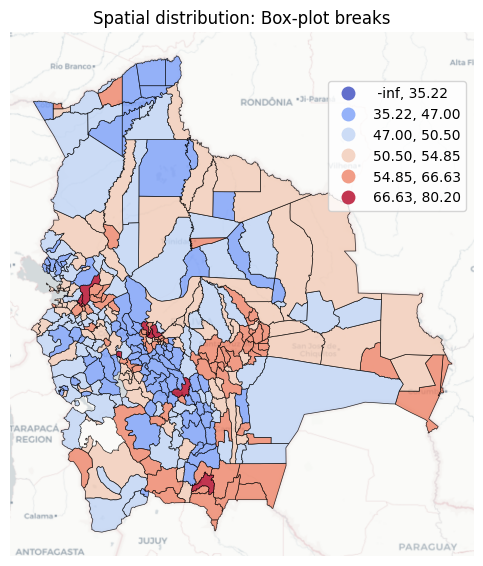

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))

gdf.plot(
    column=INDICATOR1,
    scheme='BoxPlot',
    cmap='coolwarm',
    edgecolor='k',
    linewidth=0.5,
    alpha=0.8,
    legend=True,
    ax=ax,
    legend_kwds={'bbox_to_anchor': (1.00, 0.92)}
)

cx.add_basemap(ax, crs=gdf.crs.to_string(), source=cx.providers.CartoDB.Positron, attribution=False)
plt.title('Spatial distribution: Box-plot breaks')
plt.tight_layout()
ax.axis("off")
plt.show()

### Fisher-Jenks breaks

In [10]:
gdf.explore(
    column=INDICATOR1,
    tooltip=[ADM1, ADM3, INDICATOR1, INDICATOR4],
    k=3,
    scheme='FisherJenks',
    cmap='coolwarm',
    legend=True,
    tiles='CartoDB positron',
    style_kwds=dict(color="gray", weight=0.4),
    legend_kwds=dict(colorbar=False)
)

In [11]:
mc.FisherJenks(gdf[INDICATOR1], k=3)

FisherJenks

   Interval      Count
----------------------
[35.70, 48.50] |   128
(48.50, 57.10] |   155
(57.10, 80.20] |    56

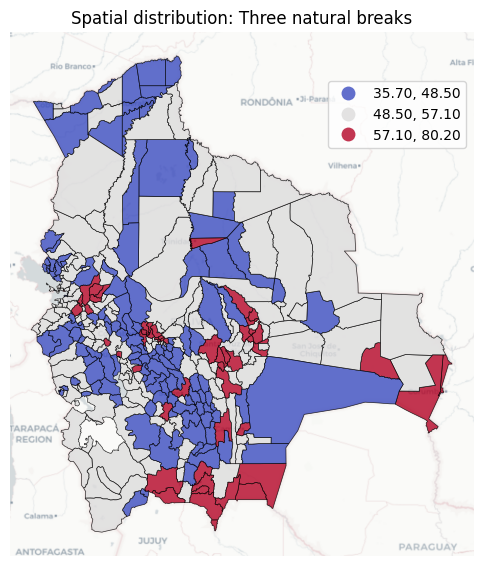

In [12]:
fig, ax = plt.subplots(figsize=(9, 6))

gdf.plot(
    column=INDICATOR1,
    scheme='FisherJenks',
    k=3,
    cmap='coolwarm',
    edgecolor='k',
    linewidth=0.5,
    alpha=0.8,
    legend=True,
    ax=ax,
    legend_kwds={'bbox_to_anchor': (1.00, 0.92)}
)

cx.add_basemap(ax, crs=gdf.crs.to_string(), source=cx.providers.CartoDB.Positron, attribution=False)
plt.title('Spatial distribution: Three natural breaks')
plt.tight_layout()
ax.axis("off")
plt.show()

## Spatial dependence

- To what extent is the performance of a region similar to that of its neighbours?
- To what extent is there an overall pattern of "clustering"?
- Where can we find statistically significant spatial clusters?
- Where can we find statistically significant spatial outliers?

### Spatial connectivity

(<Figure size 1000x1000 with 1 Axes>, <Axes: >)

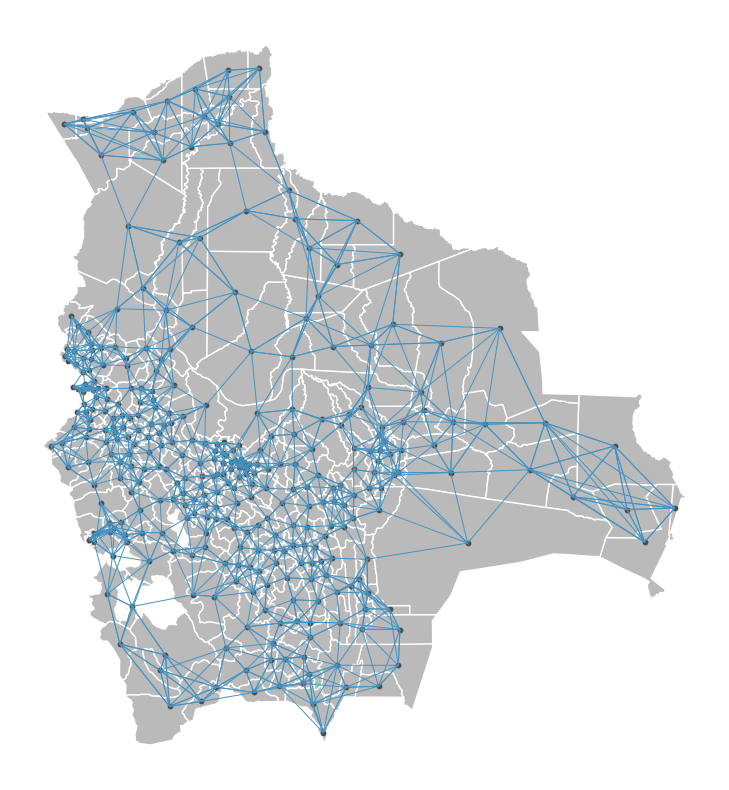

In [13]:
W = weights.KNN.from_dataframe(gdf, k=6)
W.transform = 'r'

plot_spatial_weights(W, gdf)

### Global dependence

In [14]:
df_MORAN = gdf[[ADM1, ADM3, INDICATOR1]].copy()
df_MORAN["WxINDICATOR1"] = weights.lag_spatial(W, df_MORAN[INDICATOR1])

In [15]:
px.scatter(
    df_MORAN,
    x=INDICATOR1,
    y="WxINDICATOR1",
    hover_name=ADM3,
    hover_data=[ADM1, INDICATOR1, 'WxINDICATOR1'],
    trendline="ols",
    marginal_x="box",
    marginal_y="box",
    labels=dict(data_dict)
)

### Local dependence

In [16]:
globalMoran = Moran(gdf[INDICATOR1], W)
MoranI = "{:.2f}".format(globalMoran.I)

localMoran = Moran_Local(gdf[INDICATOR1], W, permutations=999, seed=12345)

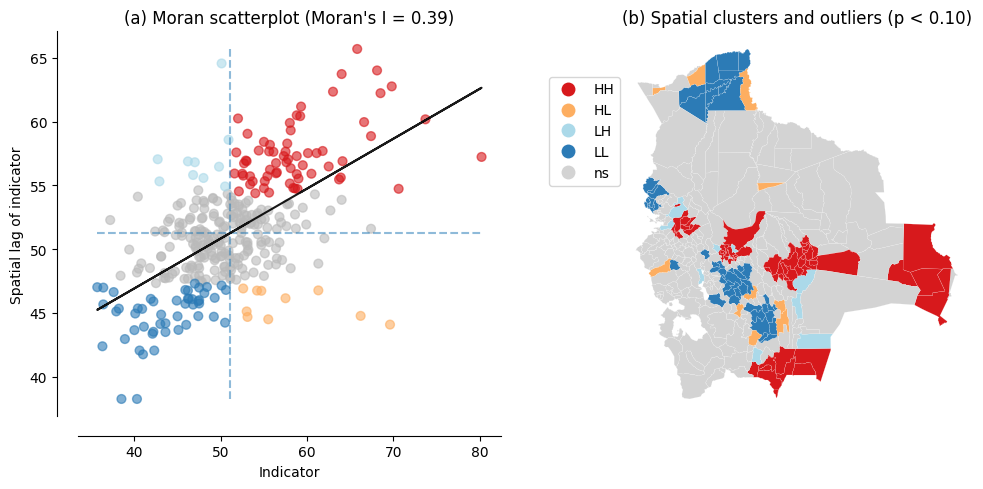

In [17]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

moran_scatterplot(localMoran, p=0.10, aspect_equal=False, zstandard=False, ax=axes[0])
lisa_cluster(localMoran, gdf, p=0.10, legend_kwds={'bbox_to_anchor': (0.02, 0.90)}, ax=axes[1])

axes[0].set_xlabel('Indicator')
axes[0].set_ylabel('Spatial lag of indicator')
axes[0].set_title(f"(a) Moran scatterplot (Moran's I = {MoranI})")
axes[1].set_title("(b) Spatial clusters and outliers (p < 0.10)")

plt.show()